# ZGT Ground-Truth Component Boxes to MedSAM Segmentation

This notebook is a segmentation-only MedSAM pipeline for the ZGT test set.

It uses the dependency-injection dataset utilities from `utils/dep_injection_util.py`:

- `BaseDataset` for dataset wiring
- `PngLoader` for loading `img.jpg` and `mask.png`
- `ConnectedComponentsBBoxFromMask` for extracting one box per connected mass component

Important verification: the original `BBoxFromMask` returns **one enclosing box** around all nonzero mask pixels. For masks with multiple disconnected masses, that can produce one oversized prompt. The notebook therefore uses `ConnectedComponentsBBoxFromMask`, which extracts one prompt box per connected component.

Pipeline:

1. Load ZGT test cases from the VersaMammo-format folder.
2. Load images and GT masks through `BaseDataset` dependency injection.
3. Extract one GT box per connected component in the mask.
4. Resize images, masks, and all boxes to `1024 x 1024` for MedSAM.
5. Run MedSAM once per GT component box.
6. Union prompt masks per image.
7. Compute Dice and save overlay visualizations.

In [2]:
from pathlib import Path
import json
import sys
from peft import LoraConfig, get_peft_model
import monai
import tqdm
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage import io
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

In [3]:
# -------------------------
# Configuration
# -------------------------
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "pipelines_and_experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent

MEDSAM_ROOT = PROJECT_ROOT / "MedSAM"
MEDSAM_SEGMENTATION_DIR = MEDSAM_ROOT / "notebooks" / "segmentation"


DATA_ROOT = "/home/jovyan/thesis_project/datasets/INbreast/INbreast Release 1.0/MassCases"

TEST_DATASET = None  # None = use fold with best detection map_50 if available. Or set e.g. "ZGT_VersaMammo_fold4".


DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
MODELS_DIR=Path("/home/jovyan/thesis_project/models")

MEDSAM_CHECKPOINT = MODELS_DIR / "medsam_vit_b.pth"
OUTPUT_ROOT = PROJECT_ROOT / "results" / "pipelines_and_experiments" / "SEG_INbreast_from_ZGT_medSAM-LoRA"

MEDSAM_IMAGE_SIZE = (1024, 1024)
MIN_COMPONENT_AREA = 1
BBOX_PADDING = 0
BBOX_CONNECTIVITY = 2  # 2 = 8-neighborhood; 1 = 4-neighborhood
MASK_THRESHOLD = 0.5
BATCH_SIZE = 1

print(f"Project root: {PROJECT_ROOT}")
print(f"CUDA available: {torch.cuda.is_available()} | device: {DEVICE}")

Project root: /home/jovyan/thesis_project/FM_thesis
CUDA available: True | device: cuda:0


In [4]:
# Imports from this repo and from MedSAM.
# PROJECT_ROOT must be on sys.path so `utils.dep_injection_util` resolves to FM_thesis/utils.
for path in [PROJECT_ROOT, MEDSAM_ROOT, MEDSAM_SEGMENTATION_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from MedSAM.segment_anything import sam_model_registry
from utils.dep_injection_util import (
    BaseDataset,
    NpzLoader,
    ConnectedComponentsBBoxFromMask,
)

In [5]:
def load_json(path: Path):
    with open(path) as f:
        return json.load(f)

TEST_ROOT = DATA_ROOT

MASK_OUT_DIR = OUTPUT_ROOT / "pred_masks"
OVERLAY_OUT_DIR = OUTPUT_ROOT / "overlays"
WEIGHTS_OUT_DIR= OUTPUT_ROOT / "weights"
# METRICS_OUT = OUTPUT_ROOT / "medsam_gt_component_prompt_metrics.csv"
# SUMMARY_OUT = OUTPUT_ROOT / "medsam_gt_component_prompt_summary.json"

print(f"Test root: {TEST_ROOT}")
print(f"Output root: {OUTPUT_ROOT}")

Test root: /home/jovyan/thesis_project/datasets/INbreast/INbreast Release 1.0/MassCases
Output root: /home/jovyan/thesis_project/FM_thesis/results/pipelines_and_experiments/SEG_INbreast_from_ZGT_medSAM-LoRA


In [6]:
class MedSAM(torch.nn.Module):
    def __init__(
        self,
        image_encoder,
        mask_decoder,
        prompt_encoder,
    ):
        super().__init__()
        self.image_encoder = image_encoder
        self.mask_decoder = mask_decoder
        self.prompt_encoder = prompt_encoder
        # freeze prompt encoder
        for param in self.prompt_encoder.parameters():
            param.requires_grad = False

    def forward(self, image, box):
        image_embedding = self.image_encoder(image)  # (B, 256, 64, 64)
        # do not compute gradients for prompt encoder
        with torch.no_grad():
            box_torch = torch.as_tensor(box, dtype=torch.float32, device=image.device)
            if len(box_torch.shape) == 2:
                box_torch = box_torch[:, None, :]  # (B, 1, 4)

            sparse_embeddings, dense_embeddings = self.prompt_encoder(
                points=None,
                boxes=box_torch,
                masks=None,
            )
        low_res_masks, _ = self.mask_decoder(
            image_embeddings=image_embedding,  # (B, 256, 64, 64)
            image_pe=self.prompt_encoder.get_dense_pe(),  # (1, 256, 64, 64)
            sparse_prompt_embeddings=sparse_embeddings,  # (B, 2, 256)
            dense_prompt_embeddings=dense_embeddings,  # (B, 256, 64, 64)
            multimask_output=False,
        )
        ori_res_masks = F.interpolate(
            low_res_masks,
            size=(image.shape[2], image.shape[3]),
            mode="bilinear",
            align_corners=False,
        )
        
        return ori_res_masks

In [7]:
class MedSAMPreprocess:
    """Convert BaseDataset numpy sample into tensors and scale boxes to MedSAM size."""

    def __init__(self, size=(1024, 1024)):
        self.size = tuple(size)

    def __call__(self, sample):
        image = sample["image"]
        mask = sample["mask"]
        boxes = sample["bbox"]

        if image.ndim == 3:
            if image.shape[0] in {1, 3}:
                image = image[0]
            elif image.shape[-1] in {1, 3}:
                image = image[..., 0]
            else:
                raise ValueError(f"Unexpected image shape: {image.shape}")

        if mask.ndim == 3:
            if mask.shape[0] == 1:
                mask = mask[0]
            elif mask.shape[-1] == 1:
                mask = mask[..., 0]
            else:
                raise ValueError(f"Unexpected mask shape: {mask.shape}")

        old_h, old_w = image.shape[:2]
        new_h, new_w = self.size

        image = image.astype(np.float32)
        image = (image - image.min()) / max(float(image.max() - image.min()), 1e-8)
        image_t = torch.from_numpy(image).float().unsqueeze(0).repeat(3, 1, 1)
        image_t = F.interpolate(image_t.unsqueeze(0), size=self.size, mode="bilinear", align_corners=False).squeeze(0)

        mask_t = torch.from_numpy((mask > 0).astype(np.uint8)).float().unsqueeze(0)
        mask_t = F.interpolate(mask_t.unsqueeze(0), size=self.size, mode="nearest").squeeze(0).to(torch.uint8)

        if boxes is None:
            box_t = torch.zeros((0, 4), dtype=torch.float32)
        else:
            box_arr = np.asarray(boxes, dtype=np.float32).reshape(-1, 4)
            box_arr[:, [0, 2]] *= new_w / old_w
            box_arr[:, [1, 3]] *= new_h / old_h
            box_t = torch.from_numpy(box_arr).float()

        sample["image"] = image_t
        sample["mask"] = mask_t
        sample["bbox"] = box_t
        sample["original_size"] = (old_h, old_w)
        sample["resized_size"] = self.size
        return sample

In [8]:
def mammo_collate_fn(batch):
    return {
        "image": torch.stack([sample["image"] for sample in batch], dim=0),
        "mask": torch.stack([sample["mask"] for sample in batch], dim=0),
        "bbox": [sample["bbox"] for sample in batch],
        "label": torch.stack([sample["label"] for sample in batch], dim=0),
        "case_id": [sample.get("case_id") for sample in batch],
        "image_path": [sample.get("image_path") for sample in batch],
        "mask_path": [sample.get("mask_path") for sample in batch],
    }


loader = NpzLoader(dtype=None)

bbox_generator = ConnectedComponentsBBoxFromMask(
    annotation_threshold=0.5,
    min_mask_area=MIN_COMPONENT_AREA,
    bbox_padding=BBOX_PADDING,
    connectivity=BBOX_CONNECTIVITY,
    allow_empty_mask=True,
)



zgt_test_dataset = BaseDataset(
    root=TEST_ROOT,
    format_loader=loader,
    bbox_generator=bbox_generator,
    transforms=MedSAMPreprocess(MEDSAM_IMAGE_SIZE),
    split="all",
    return_metadata=False,
)

zgt_test_loader = DataLoader(
    zgt_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=mammo_collate_fn,
)

print(f"Loaded {len(zgt_test_loader)} ZGT train images")

Loaded 108 ZGT train images


In [10]:
def dice_score(pred_mask: torch.Tensor, gt_mask: torch.Tensor) -> float:
    pred = pred_mask.bool()
    gt = gt_mask.bool()
    denom = pred.sum() + gt.sum()
    if denom.item() == 0:
        return 1.0
    return float((2 * (pred & gt).sum() / denom).item())



def to_display_image(image_tensor: torch.Tensor) -> np.ndarray:
    img = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    img = (img - img.min()) / max(float(img.max() - img.min()), 1e-8)
    return img


def overlay_result(image_tensor, gt_mask, pred_mask, boxes, title, out_path):
    image = to_display_image(image_tensor)
    gt = gt_mask.detach().cpu().squeeze().numpy().astype(bool)
    pred = pred_mask.detach().cpu().squeeze().numpy().astype(bool)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image, cmap="gray")

    gt_rgba = np.zeros((*gt.shape, 4), dtype=np.float32)
    gt_rgba[..., 1] = 1.0
    gt_rgba[..., 3] = gt * 0.35
    ax.imshow(gt_rgba)

    pred_rgba = np.zeros((*pred.shape, 4), dtype=np.float32)
    pred_rgba[..., 0] = 1.0
    pred_rgba[..., 3] = pred * 0.35
    ax.imshow(pred_rgba)

    for i, box in enumerate(boxes.detach().cpu().numpy() if boxes is not None else []):
        x1, y1, x2, y2 = box.tolist()
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="yellow", linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x1, max(0, y1 - 4), f"component {i + 1}", color="black", fontsize=8, bbox={"facecolor": "yellow", "alpha": 0.8, "pad": 1})

    ax.set_title(title)
    ax.set_axis_off()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight", pad_inches=0, dpi=160)
    plt.close(fig)

In [13]:
batch=next(iter(zgt_test_dataset))

print(batch.keys())

dict_keys(['image', 'mask', 'bbox', 'label', 'original_size', 'resized_size'])


In [11]:
def forward_medsam_multi_box_batch(model, images, boxes_batch, device):
    """
    images: (B, C, H, W)
    boxes_batch: list length B, each item is (K_i, 4)
    returns: (B, 1, H, W)
    """

    batch_logits = []

    for i in range(images.shape[0]):
        
        image_i = images[i].unsqueeze(0)  # (1, C, H, W)
        boxes_i = boxes_batch[i]

        
        if boxes_i is None or len(boxes_i) == 0:
            _, _, H, W = images.shape
            empty_logits = torch.zeros(
                (1, 1, H, W),
                device=device,
                dtype=images.dtype,
            )
            batch_logits.append(empty_logits)
            continue

        logits_per_box = []

        for box in boxes_i:
            
            box = torch.as_tensor(box, dtype=torch.float32, device=device)

            if box.ndim == 1:
                box = box.unsqueeze(0)  # (4,) -> (1, 4)


            pred_logits = model(image_i, box)
            logits_per_box.append(pred_logits)

        logits_per_box = torch.cat(logits_per_box, dim=0)
        union_logits = logits_per_box.max(dim=0, keepdim=True).values

        batch_logits.append(union_logits)

    batch_logits = torch.cat(batch_logits, dim=0)

    return batch_logits

In [15]:
# -------------------------
# Load finetuned checkpoint
# -------------------------
ckpt_path = MODELS_DIR / "medsam_LoRA_ZGT_from_gt_masks_fold4.pth"

sam_model = sam_model_registry["vit_b"](checkpoint=MEDSAM_CHECKPOINT)

model = MedSAM(
    image_encoder=sam_model.image_encoder,
    mask_decoder=sam_model.mask_decoder,
    prompt_encoder=sam_model.prompt_encoder,
).to(DEVICE)


config = LoraConfig(
    r=8,
    lora_alpha=8,
    target_modules=["qkv"],
    lora_dropout=0.1,
    bias="none"
)

model = get_peft_model(model, config)

checkpoint = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model"])

model.eval()


MASK_OUT_DIR.mkdir(parents=True, exist_ok=True)
OVERLAY_OUT_DIR.mkdir(parents=True, exist_ok=True)

rows = []

with torch.no_grad():
    for batch_idx, batch in enumerate(zgt_test_loader, start=1):
        images = batch["image"].to(DEVICE)
        gt_masks = batch["mask"].to(DEVICE).float()
        boxes_list = batch["bbox"]
        case_ids = batch["case_id"]

        boxes_batch = [
            box.to(DEVICE).float() if torch.is_tensor(box)
            else torch.as_tensor(box, dtype=torch.float32, device=DEVICE)
            for box in boxes_list
        ]

        medsam_logits = forward_medsam_multi_box_batch(
            model,
            images,
            boxes_batch,
            DEVICE,
        )

        pred_masks = (torch.sigmoid(medsam_logits) > MASK_THRESHOLD).float()

        for i in range(images.shape[0]):
            image = images[i]
            gt_mask = gt_masks[i]
            pred_mask = pred_masks[i]
            boxes = boxes_batch[i]
            case_id = case_ids[i]

            dice = dice_score(
                pred_mask,
                gt_mask,
            )

#             io.imsave(
#                 MASK_OUT_DIR / f"{case_id}_pred_union.png",
#                 (pred_mask.detach().cpu().squeeze().numpy() * 255).astype(np.uint8),
#                 check_contrast=False,
#             )

#             overlay_result(
#                 image_tensor=image.detach().cpu(),
#                 gt_mask=gt_mask.detach().cpu(),
#                 pred_mask=pred_mask.detach().cpu(),
#                 boxes=boxes.detach().cpu(),
#                 title=f"{case_id} | Dice={float(dice):.3f} | component prompts={len(boxes)}",
#                 out_path=OVERLAY_OUT_DIR / f"{case_id}.png",
#             )

            rows.append({
                "case_id": case_id,
                "dice": float(dice),
                "pred_mask": pred_mask,
                "num_component_boxes": int(len(boxes)),
                "gt_area": int(gt_mask.bool().sum().item()),
                "pred_area": int(pred_mask.bool().sum().item()),
            })

        if batch_idx % 5 == 0 or batch_idx == len(zgt_test_loader):
            print(f"Processed batch {batch_idx}/{len(zgt_test_loader)}")

Processed batch 5/108
Processed batch 10/108
Processed batch 15/108
Processed batch 20/108
Processed batch 25/108
Processed batch 30/108
Processed batch 35/108
Processed batch 40/108
Processed batch 45/108
Processed batch 50/108
Processed batch 55/108
Processed batch 60/108
Processed batch 65/108
Processed batch 70/108
Processed batch 75/108
Processed batch 80/108
Processed batch 85/108
Processed batch 90/108
Processed batch 95/108
Processed batch 100/108
Processed batch 105/108
Processed batch 108/108


In [16]:
sum_dice=0
for sample in rows:
    sample_dice=sample["dice"]
    sum_dice+=sample_dice
    
avg=sum_dice/len(rows)

print(avg)
    

0.8601949267365314


In [14]:
print(sum_dice)

0.520288145635277


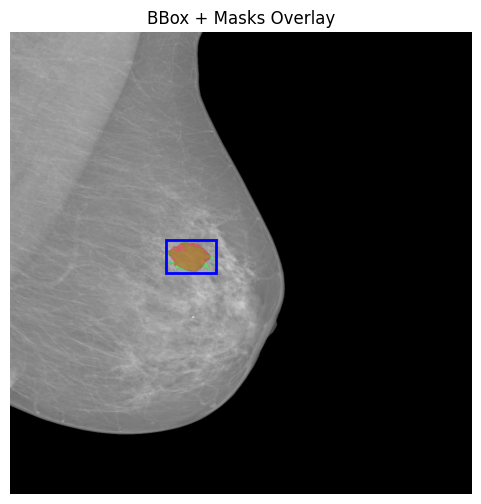

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np


def show_bbox_overlay(image, bbox, gt_mask=None, pred_mask=None):
    """
    Overlay bbox (+ optional masks) on an image.

    Parameters
    ----------
    image : torch.Tensor or np.ndarray
        Shape can be (H,W), (H,W,C), or (C,H,W)
    bbox : array-like
        Shape (4,) or (1,4), format [x_min, y_min, x_max, y_max]
    gt_mask : torch.Tensor or np.ndarray, optional
    pred_mask : torch.Tensor or np.ndarray, optional
    """

    def to_numpy(x):
        if x is None:
            return None

        if torch.is_tensor(x):
            x = x.detach().cpu().numpy()

        return x

    image = to_numpy(image)
    gt_mask = to_numpy(gt_mask)
    pred_mask = to_numpy(pred_mask)
    bbox = to_numpy(bbox)

    # Convert image from (C,H,W) -> (H,W,C)
    if image is not None:
        if image.ndim == 3 and image.shape[0] in [1, 3, 4]:
            image = np.transpose(image, (1, 2, 0))

        # Convert (H,W,1) -> (H,W)
        if image.ndim == 3 and image.shape[-1] == 1:
            image = image[..., 0]

    # Squeeze masks to (H,W)
    if gt_mask is not None:
        gt_mask = np.squeeze(gt_mask)

    if pred_mask is not None:
        pred_mask = np.squeeze(pred_mask)

    fig, ax = plt.subplots(figsize=(6, 6))

    # Show image
    if image is not None:
        if image.ndim == 2:
            ax.imshow(image, cmap="gray")
        else:
            ax.imshow(image)

    # GT mask (green)
    if gt_mask is not None:
        gt = np.zeros((*gt_mask.shape, 4))
        gt[..., 1] = gt_mask
        gt[..., 3] = gt_mask * 0.4
        ax.imshow(gt)

    # Pred mask (red)
    if pred_mask is not None:
        pred = np.zeros((*pred_mask.shape, 4))
        pred[..., 0] = pred_mask
        pred[..., 3] = pred_mask * 0.4
        ax.imshow(pred)

    # Handle bbox shape (4,) or (1,4)
    bbox = np.asarray(bbox)

    if bbox.ndim == 2:
        bbox = bbox[0]

    x_min, y_min, x_max, y_max = bbox

    rect = patches.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        linewidth=2,
        edgecolor="blue",
        facecolor="none",
    )

    ax.add_patch(rect)

    ax.set_title("BBox + Masks Overlay")
    ax.axis("off")
    plt.show()

sample=zgt_test_dataset[25]
    
img=sample["image"]
bbox=sample["bbox"]
gt_mask_sample = sample["mask"]
pred_mask_sample = rows[25]["pred_mask"]



show_bbox_overlay(
    image=img,           # or your original image if you have it
    bbox=bbox,
    gt_mask=gt_mask_sample,
    pred_mask=pred_mask_sample
)

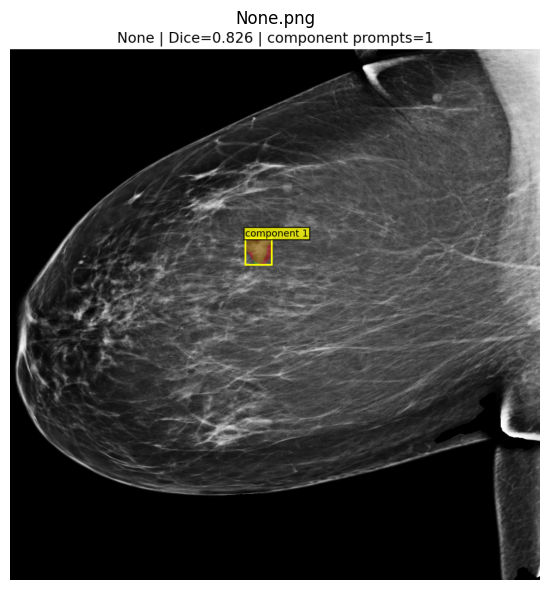

In [17]:
# Preview a few overlays.
preview_paths = sorted(OVERLAY_OUT_DIR.glob("*.png"))[:6]
if not preview_paths:
    print("No overlays generated yet.")
else:
    fig, axes = plt.subplots(len(preview_paths), 1, figsize=(9, 6 * len(preview_paths)))
    if len(preview_paths) == 1:
        axes = [axes]
    for ax, path in zip(axes, preview_paths):
        ax.imshow(io.imread(path))
        ax.set_title(path.name)
        ax.set_axis_off()
    plt.tight_layout()